# 04 · Generalization & the Unknowable Regime

Beyond anomaly detection: a regression covariate-shift track (KGA refuses unstable importance
weighting), and a **clean non-identifiability witness** — two worlds with identical evidence law
but opposite benefit, where KGA must abstain 100% of the time.


In [1]:
import os, json, glob, numpy as np
REPO=os.path.abspath(os.getcwd())
while REPO!='/' and not os.path.exists(os.path.join(REPO,'scripts','rebuild_kbound.sh')): REPO=os.path.dirname(REPO)
RES=os.path.join(REPO,'experiments','kbound','results'); FIG=os.path.join(REPO,'docs','research','kbound','figures')
ARCH=os.path.join(REPO,'experiments','elara_u','score_archive'); TV=os.path.join(REPO,'experiments','kbound','theory_validation')
from IPython.display import Image, display
def jload(p):
    fp=p if os.path.isabs(p) else os.path.join(RES,p)
    return json.load(open(fp)) if os.path.exists(fp) else {}
def fig(fn,w=720):
    p=os.path.join(FIG,fn)
    if os.path.exists(p): display(Image(filename=p,width=w))
print('repo:',REPO)

repo: /sessions/optimistic-amazing-ritchie/mnt/uav/AutoML_Flagship_V8


In [2]:
r=jload('regression_covariate.json')
print('### Regression covariate-shift'); print(' decisions:',r.get('decision_counts')); print(' mean_MSE:',r.get('mean_MSE'))
w=jload('witness_clean.json')
print('\n### Non-identifiability witness'); print(' abstain_rate:',w.get('abstain_rate'))
print(' all Z features indistinguishable (KS p>0.05):',w.get('all_Z_features_p>0.05'))
print(' world0 mean B = %.3f , world1 mean B = %.3f (opposite sign)'%(w.get('world0_mean_B',0),w.get('world1_mean_B',0)))

### Regression covariate-shift
 decisions: {'ADAPT': 0, 'FREEZE': 11, 'ABSTAIN': 61}
 mean_MSE: {'always_adapt(IW)': 0.33760123811511755, 'always_freeze': 0.25125518532302443, 'K_Bound': 0.25125518532302443, 'oracle': 0.2511881678882004}

### Non-identifiability witness
 abstain_rate: 1.0
 all Z features indistinguishable (KS p>0.05): True
 world0 mean B = -1.000 , world1 mean B = 1.000 (opposite sign)


## Live witness: identical Z-law, opposite truth → abstain


In [3]:
import numpy as np
from scipy.stats import skew, ks_2samp
from sklearn.ensemble import GradientBoostingRegressor
rng=np.random.default_rng(0); rows=[]
for _ in range(300):
    world=int(rng.integers(0,2)); X=rng.normal(0,1,400)
    f0=(X>0).astype(int); fa=(X<0).astype(int); Y=(X>0).astype(int) if world==0 else (X<0).astype(int)
    B=float(np.mean(fa==Y)-np.mean(f0==Y))
    Z=[float(np.mean(X>0)),float(np.std(X)),float(ks_2samp(X,rng.normal(0,1,400)).statistic),float(np.mean(f0)),float(skew(X))]
    rows.append((world,Z,B))
Xz=np.array([r[1] for r in rows]); B=np.array([r[2] for r in rows]); wld=np.array([r[0] for r in rows])
ks_p=[ks_2samp(Xz[wld==0,j],Xz[wld==1,j]).pvalue for j in range(Xz.shape[1])]
Bh=np.zeros(len(B))
from sklearn.model_selection import KFold
for tr,te in KFold(5,shuffle=True,random_state=0).split(Xz):
    g=GradientBoostingRegressor(n_estimators=150,max_depth=2,random_state=0).fit(Xz[tr],B[tr]); Bh[te]=g.predict(Xz[te])
eps=float(np.quantile(np.abs(Bh-B),0.9)); dec=np.where(Bh-eps>0,'ADAPT',np.where(Bh+eps<0,'FREEZE','ABSTAIN'))
print('Z-law KS p-values across worlds (all>0.05 => indistinguishable):',[round(p,2) for p in ks_p])
print('world means: B0=%.2f  B1=%.2f (opposite)'%(B[wld==0].mean(),B[wld==1].mean()))
print('KGA abstain rate = %.0f%%'%(100*np.mean(dec=='ABSTAIN')))

Z-law KS p-values across worlds (all>0.05 => indistinguishable): [np.float64(0.96), np.float64(0.94), np.float64(0.8), np.float64(0.96), np.float64(0.16)]
world means: B0=-1.00  B1=1.00 (opposite)
KGA abstain rate = 100%


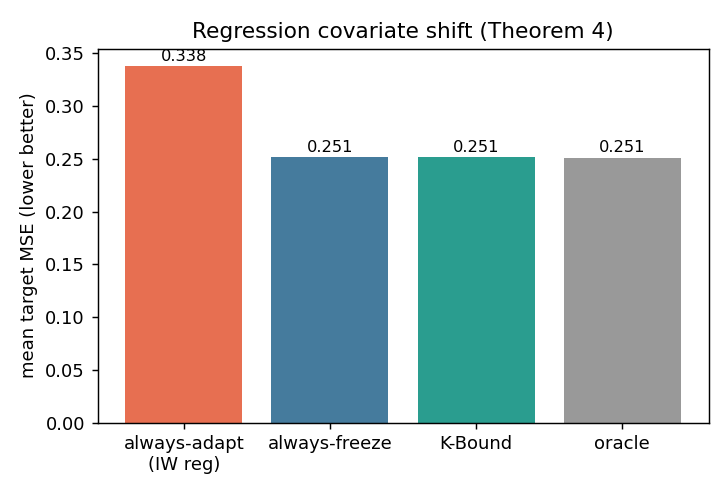

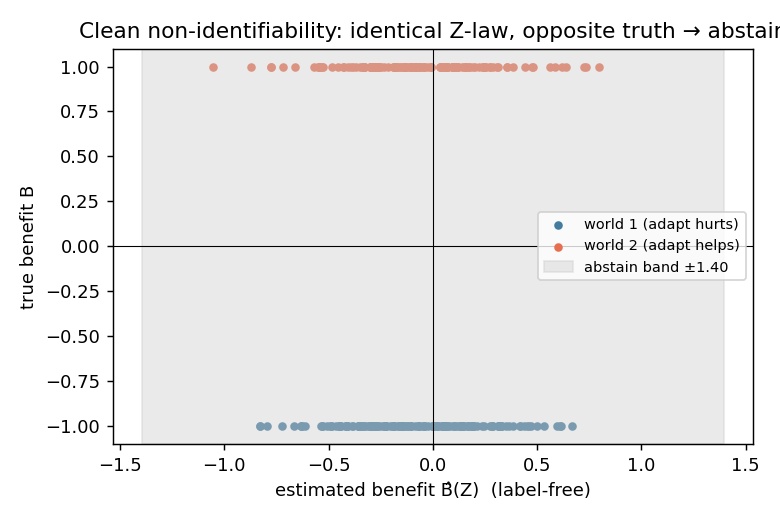

In [4]:
fig('fig_regression.png'); fig('fig_witness_clean.png')